# DP0.2 Recovered microlensing simulated light curves dataset

This dataset comprises 43 runs, each containing 2500 simulated microlensing events within a circular region of 0.1-degree radius, derived from the [Data Preview 0.2 (DP0.2)](https://dp0-2.lsst.io) simulated region by the Vera C. Rubin Observatory. For general information about the DP0 program, visit [dp0.lsst.io](https://dp0.lsst.io).

## Dataset description

The dataset includes four system types: `BS` (Binary Star), `FFP` (Free-Floating Planets), `BH` (Black Holes), and `PS` (Planetary system). Each system type is simulated using a specific microlensing model (e.g., PSPL, FSPL, USBL) with parameters computed using functions from the [`ulens_utils.py` module](https://github.com/nowokaren/ulens_lsst/blob/main/ulens_lsst/ulens_utils.py) (source: Anibal Varela).

Each simulated light curve is generated from an average of 450 sources injected into and extracted from DP0.2 images (termed `calexp`) which contains the respective event. The injection process uses the [`VisitInjectTask`](https://pipelines.lsst.io/modules/lsst.source.injection/tasks/lsst.source.injection.VisitInjectTask.html), which injects synthetic sources into single-frame visits using the GalSim package. Measurements are performed using the [`ForcedMeasurementTask`](https://pipelines.lsst.io/modules/lsst.meas.base/tasks/lsst.meas.base.forcedMeasurement.ForcedMeasurementTask.html), which measure sources flux and other properties based on a reference catalog.

###

Disclaimers:
- Error in the simulation with run_id = 6. The most probable reason is that RSP was undergoing its schudeled Thursday maintenance.
- Other disclaimer? 

## Data Files

- **`dp0_data-events.parquet`**: Contains event metadata, including coordinates (`ra`, `dec`), system type, model, and microlensing parameters
    - columns starting with
        - `param_`: simulated parameters using a predefined microlensing parameters from Genulens, others with a defined distribution corresponding to the system type and AstroDataLab sources catalog.
        - `param-pylima_`: retrived pyLIMA parameters after simulation
- **`dp0_calexps-photometry.parquet`**: Contains photometry data, including simulated magnitudes, measured magnitudes (`meas_mag`), errors, and flags for each event.





In [12]:
import pyarrow.parquet as pq
import pandas as pd

events_file = 'dp0_data-events.parquet'
table = pq.read_table(events_file)
print(f'{"Column":25} {"Type":7} Description')
print("-"*50)

for field in table.schema:
    desc = field.metadata.get(b'description', b'').decode() if field.metadata else ''
    print(f'{field.name:25} {str(field.type):7} {desc}')



Column                    Type    Description
--------------------------------------------------
event_id                  int64   Unique identifier for the microlensing event.
ra                        double  Right ascension of the event source (degrees).
dec                       double  Declination of the event source (degrees).
model                     string  Microlensing model type (e.g., PSPL, FSPL).
system_type               string  Type of lensing system (e.g., PS, BS, BH, FFP).
points                    int64   Number of data points in the light curve.
logL                      double  Logarithm of the luminosity of the source star.
logTe                     double  Logarithm of the effective temperature of the source star.
D_L                       double  Distance to the lens (kpc).
D_S                       double  Distance to the source (kpc).
mu_rel                    double  Relative proper motion between lens and source (mas/yr).
cadence_noise             string  Des

In [13]:
photo_path='dp0_calexps-photometry.parquet'
table = pq.read_table(photo_path)
print(f'{"Column":25} {"Type":7} Description')
print("-"*50)

for field in table.schema:
    desc = field.metadata.get(b'description', b'').decode() if field.metadata else ''
    print(f'{field.name:25} {str(field.type):7} {desc}')

Column                    Type    Description
--------------------------------------------------
event_id                  int64   Unique identifier for the microlensing event.
calexp_id                 int64   Unique identifier for the calibrated exposure.
time                      double  Observation time (JD).
band                      string  Photometric band (e.g., u, g, r, i, z, y).
ideal_mag                 double  Ideal (unblended) magnitude of the source.
meas_mag                  double  Measured magnitude including blending.
meas_mag_err              double  Error in the measured magnitude.
meas_flux                 double  Measured flux of the source.
meas_flux_err             double  Error in the measured flux.
magnification             double  Microlensing magnification factor at the observation time.
injection_flag            int64   Indicates whether the data point had any flag during injection (non-zero) or 0 if none.
measure_flag              string  Flag describing t

### Data set visualization
- sky map with injected events
- Event plotting
- parameters distribution



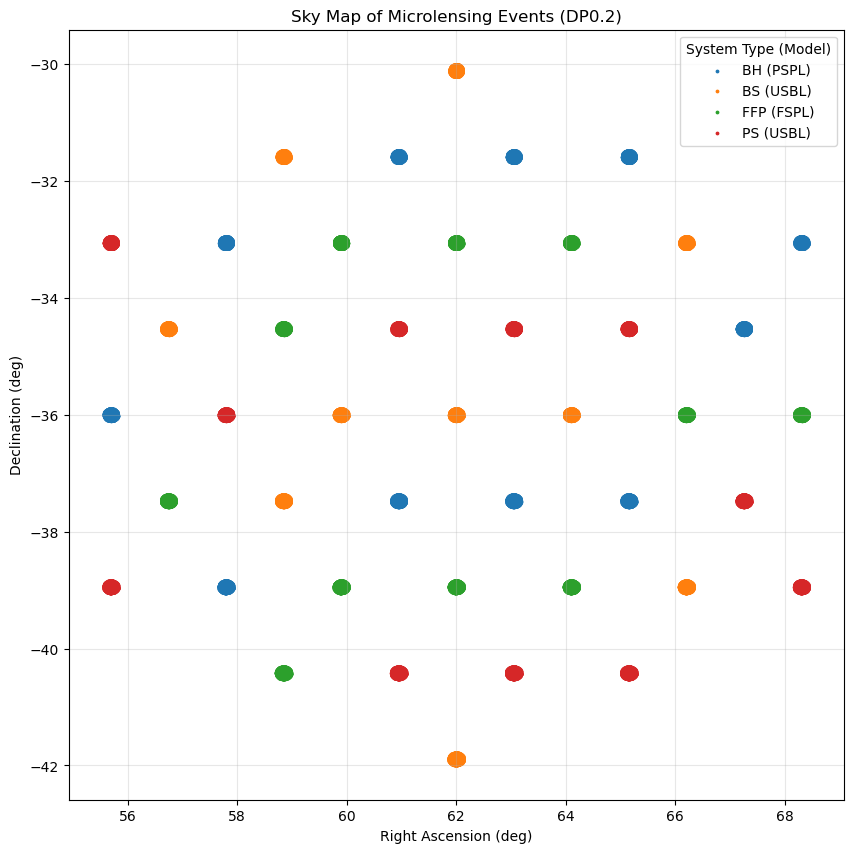

In [3]:
import pyarrow.parquet as pq
import pyarrow.compute as pc
import numpy as np
import matplotlib.pyplot as plt
events_path = 'dp0_data-events.parquet'
photometry_path = 'dp0_calexps-photometry.parquet'

events_table = pq.read_table(
    events_path,
    columns=['event_id', 'ra', 'dec', 'system_type', 'model', 'points']
)
if not events_table:
    raise ValueError(f"No data found in {events_path}")

events_data = events_table.to_pandas()
ra = events_data['ra'].to_numpy()
dec = events_data['dec'].to_numpy()
system_types = events_data['system_type'].to_numpy()
models = events_data['model'].to_numpy()
points = events_data['points'].to_numpy()

system_type_labels = np.array([f"{st} ({m})" for st, m in zip(system_types, models)])
unique_system_types = np.unique(system_type_labels)

fig, ax = plt.subplots(figsize=(10,10))

colors = plt.colormaps['tab10']
system_type_colors = {stype: colors(i % 10) for i, stype in enumerate(unique_system_types)}

for system_type in unique_system_types:
    mask = system_type_labels == system_type
    ax.scatter(
        ra[mask],
        dec[mask],
        s=3,
        c=[system_type_colors[system_type]],
        label=system_type
    )
    
ax.set_xlabel('Right Ascension (deg)')
ax.set_ylabel('Declination (deg)')
ax.set_title('Sky Map of Microlensing Events (DP0.2)')
ax.grid(True, alpha=0.3)
ax.legend(title='System Type (Model)', loc='best')

plt.show()


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pyarrow.parquet as pq
import pyarrow.compute as pc

def plot_event(
    event_id,
    events_path = 'dp0_data-events.parquet',
    photometry_path = 'dp0_calexps-photometry.parquet',
    bands = None,
    filter_flags = False,
    ax = None,
    colors = None
):
    default_colors = {
        "u": "purple",
        "g": "green",
        "r": "red",
        "i": "orange",
        "z": "brown",
        "y": "blue"
    }
    colors = colors or default_colors

    if not all(os.path.exists(p) for p in [events_path, photometry_path]):
        raise FileNotFoundError(f"One or both Parquet files not found: {events_path}, {photometry_path}")

    filters = [('event_id', '=', event_id)]
    events_table = pq.read_table(events_path, filters=filters)
    if not events_table:
        raise ValueError(f"No data found for event_id {event_id}" + 
                         (f" and run_id {run_id}" if run_id else "") + 
                         f" in {events_path}")

    photometry_table = pq.read_table(photometry_path, filters=filters)
    if not photometry_table:
        raise ValueError(f"No photometry data found for event_id {event_id}" + 
                         (f" and run_id {run_id}" if run_id else "") + 
                         f" in {photometry_path}")

    events_df = events_table.to_pandas()
    photometry_df = photometry_table.to_pandas()

    bands = bands or sorted(photometry_df['band'].unique())

    if filter_flags:
        photometry_df = photometry_df[
            (photometry_df['measure_flag'] == '') & (photometry_df['injection_flag'] == 0)
        ]

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    for band in bands:
        band_data = photometry_df[photometry_df['band'] == band]
        if not band_data.empty:
            ax.errorbar(
                band_data['time'],
                band_data['meas_mag'],
                yerr=abs(band_data['meas_mag_err']),
                fmt='o',
                markersize=3,
                color=colors.get(band, 'black'),
                alpha=0.8,
                label=f'{band}_meas'
            )
            ax.plot(
                band_data['time'],
                band_data['ideal_mag'],
                '.',
                ms=1,
                color=colors.get(band, 'black'),
                label=f'{band}_ideal',
                alpha=0.5
            )

    event_row = events_df.iloc[0]
    params = {
        key.replace('param_', ''): value
        for key, value in event_row.items()
        if key.startswith('param_') and not key.startswith('param-pylima_')
    }
    model = event_row['model']
    system_type = event_row['system_type']
    ra = event_row['ra']
    dec = event_row['dec']

    # Set plot properties
    ax.set_xlabel('Time (MJD)')
    ax.set_ylabel('Magnitude')
    ax.invert_yaxis()
    ax.set_title(f'Event {event_id} ({system_type} - {model})')
    ax.legend(loc=(1.01,0))
    ax.grid(True, alpha=0.3)

    return ax



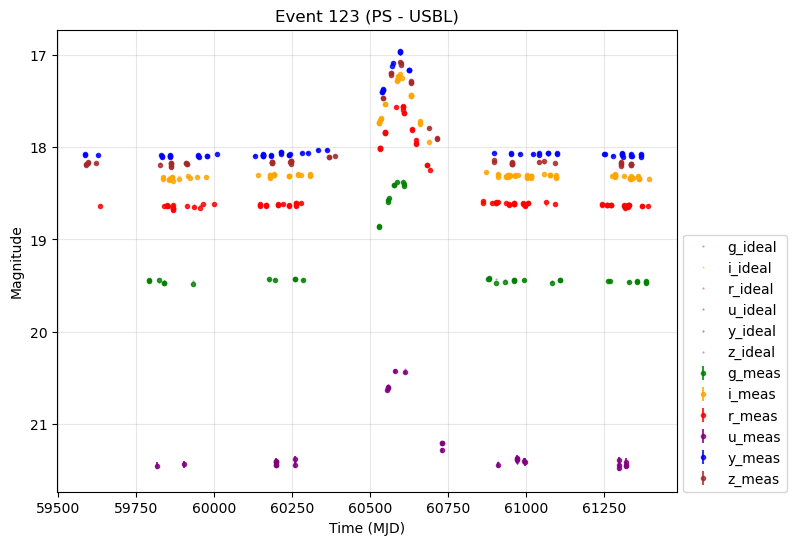

<Axes: title={'center': 'Event 123 (PS - USBL)'}, xlabel='Time (MJD)', ylabel='Magnitude'>

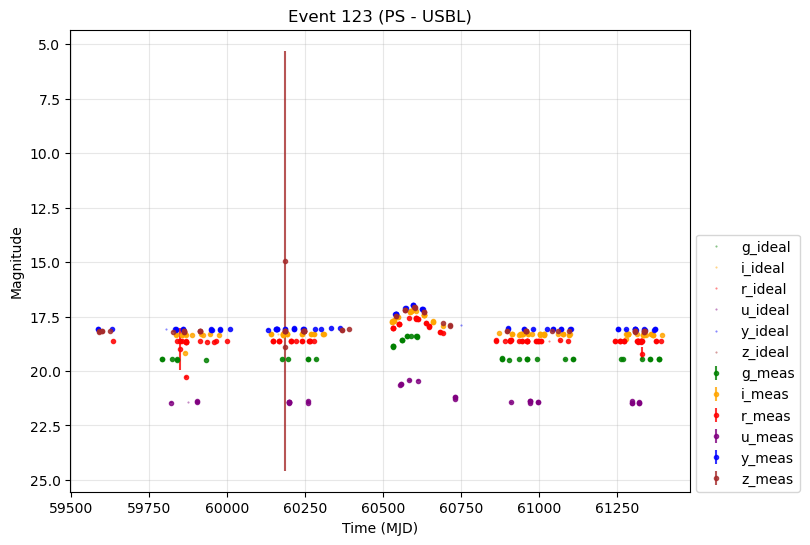

In [11]:

plot_event(
    event_id=123,
    filter_flags=True,
)
plt.show()

plot_event(
    event_id=123,
    filter_flags=False
)


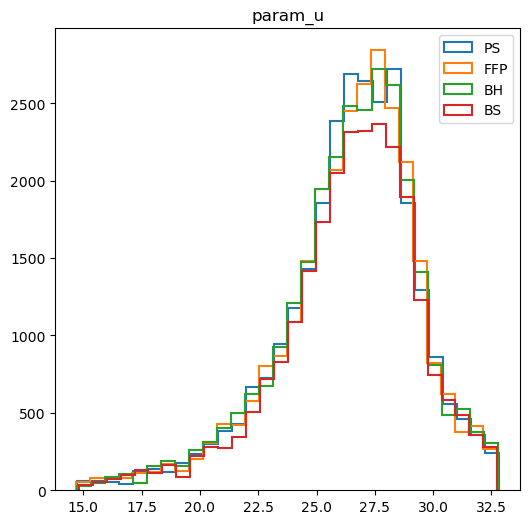

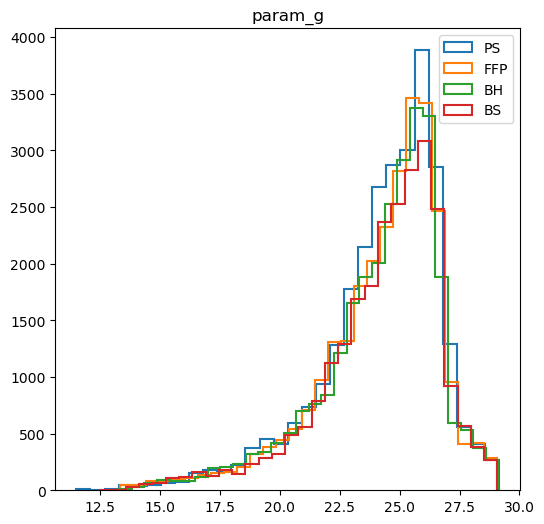

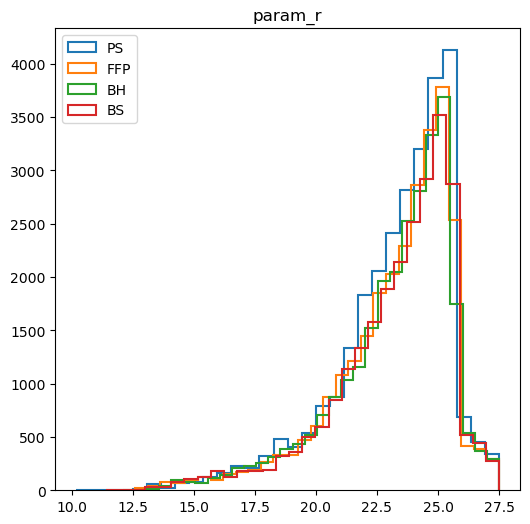

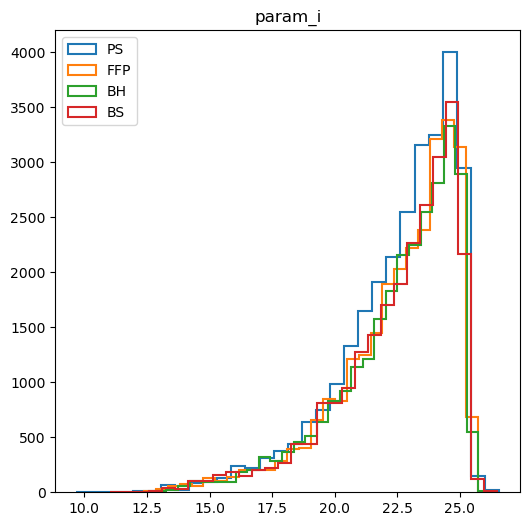

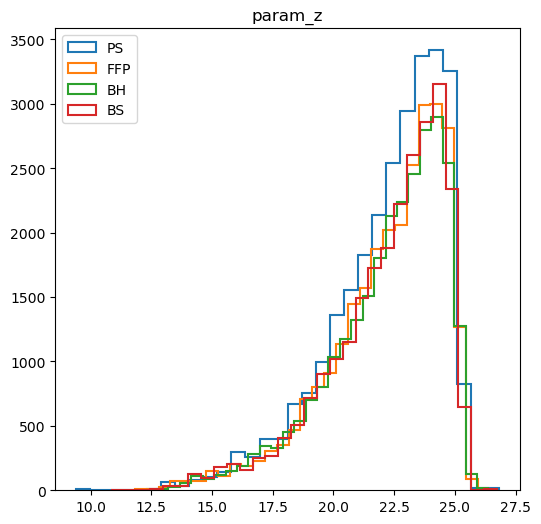

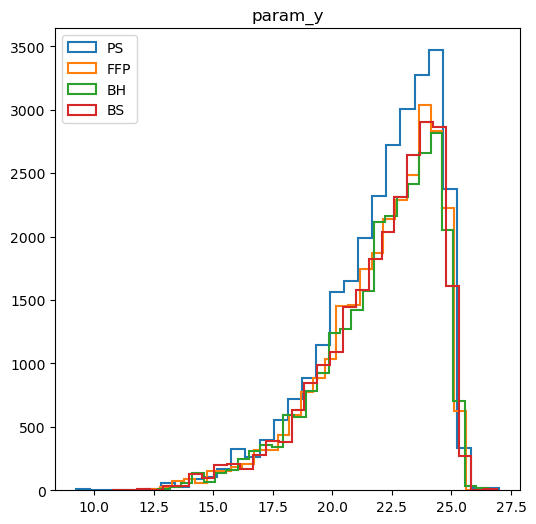

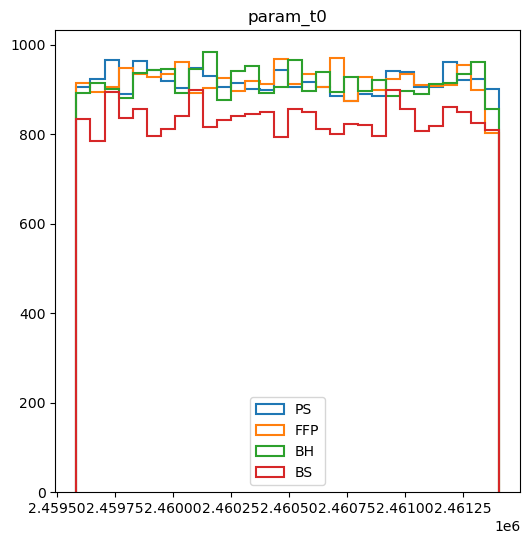

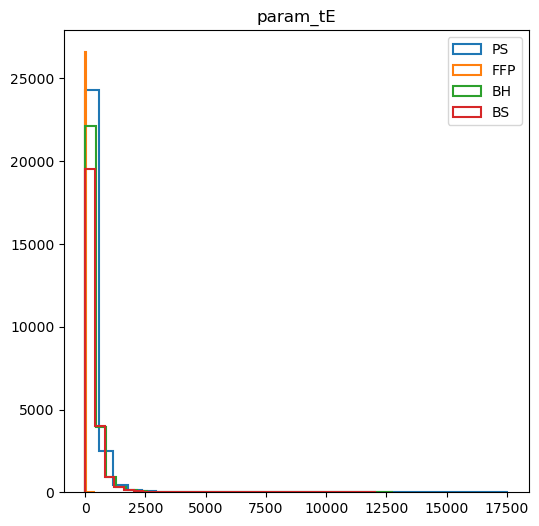

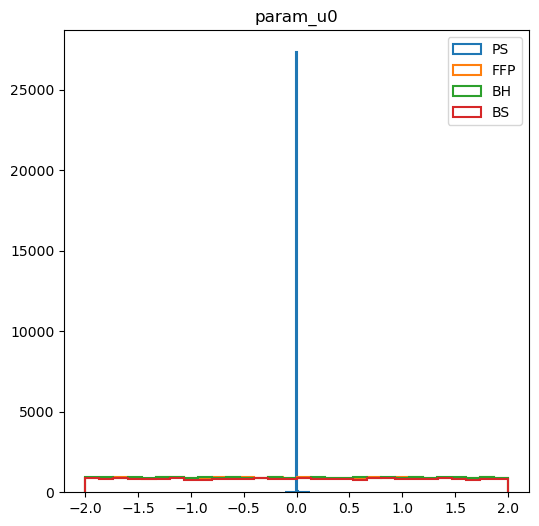

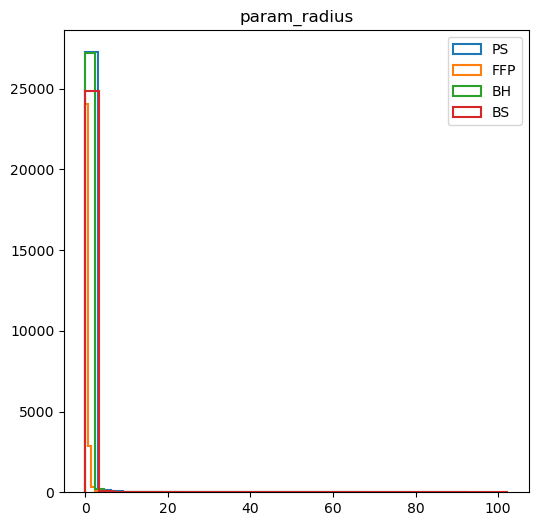

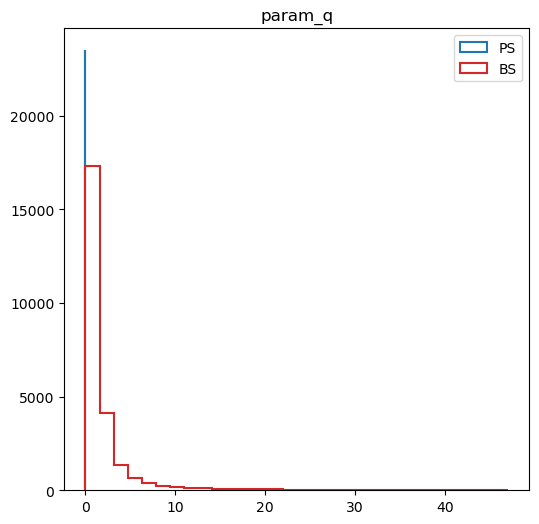

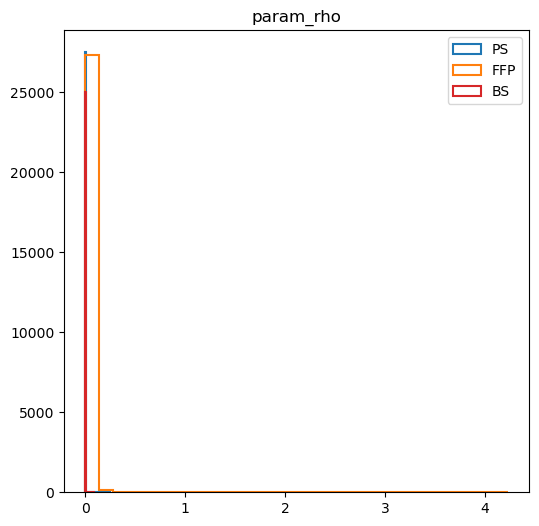

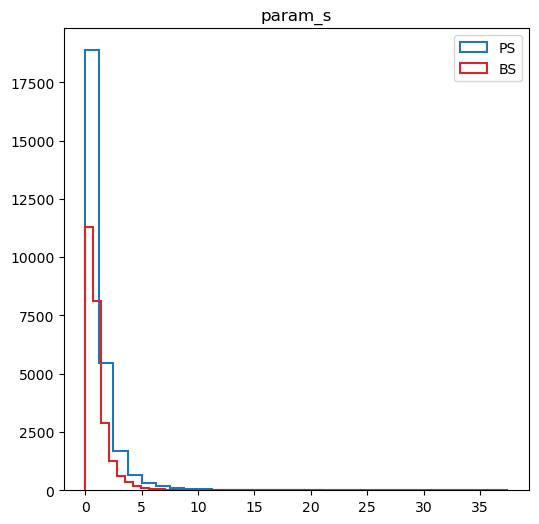

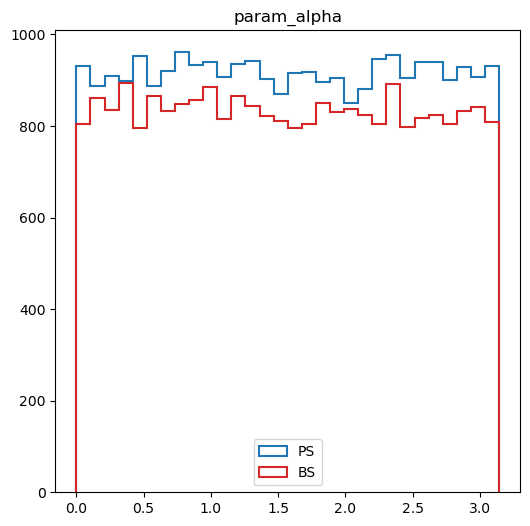

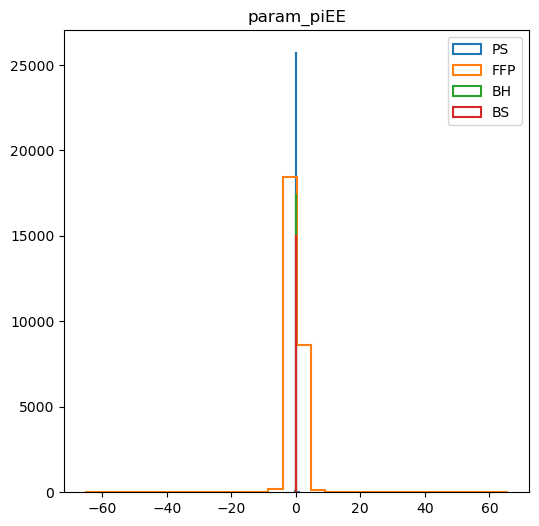

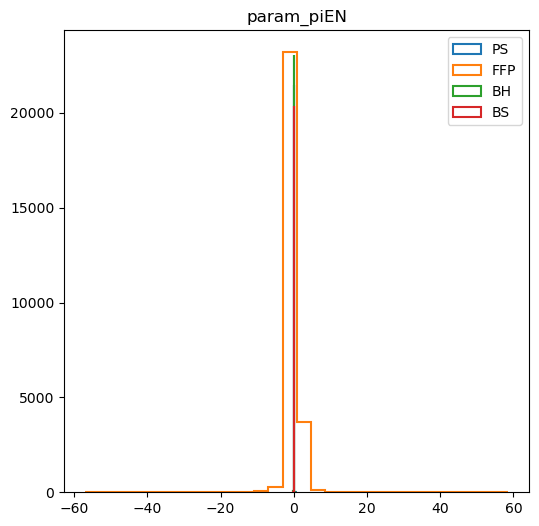

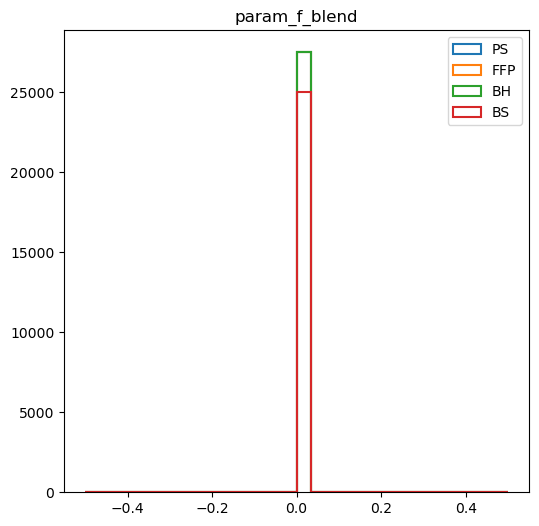

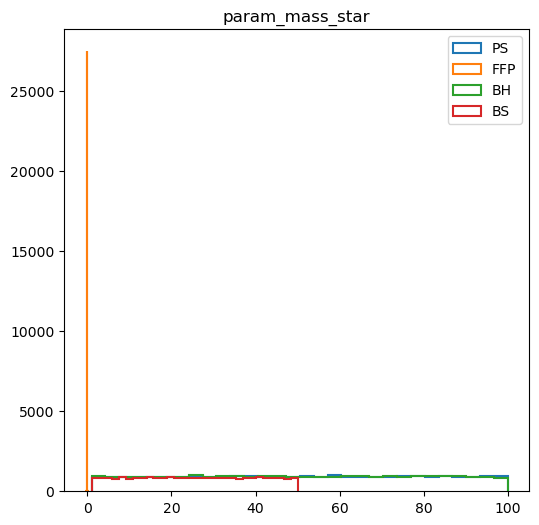

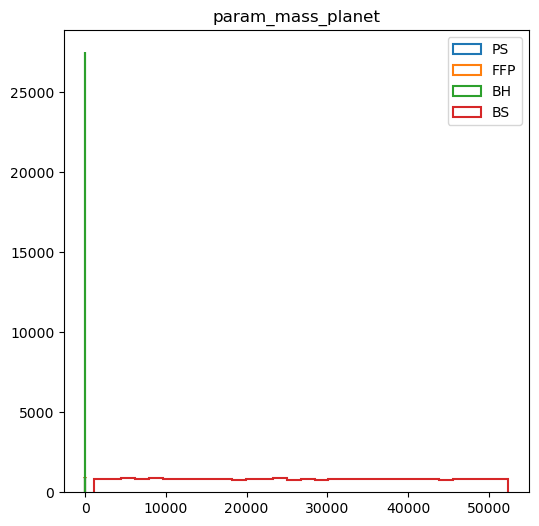

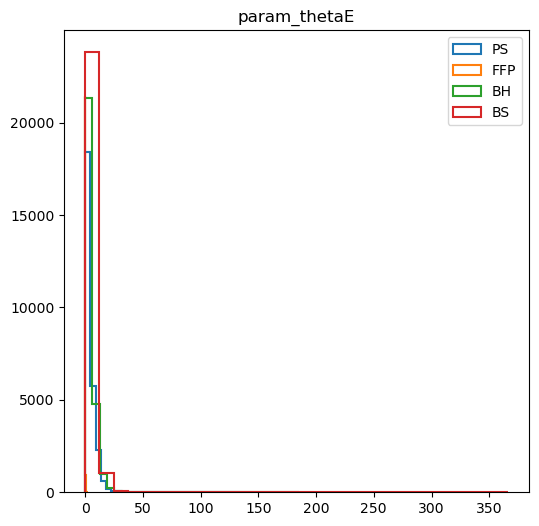

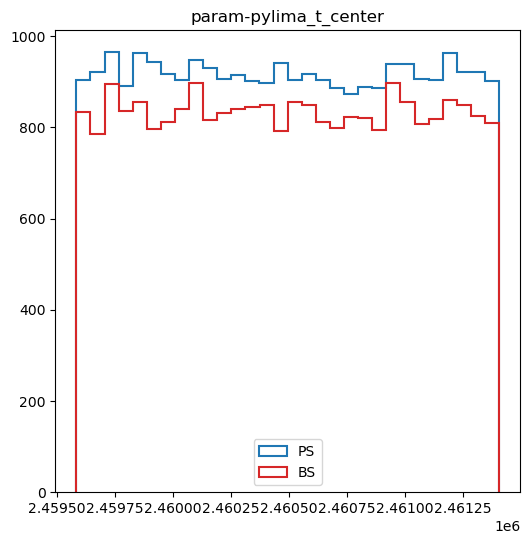

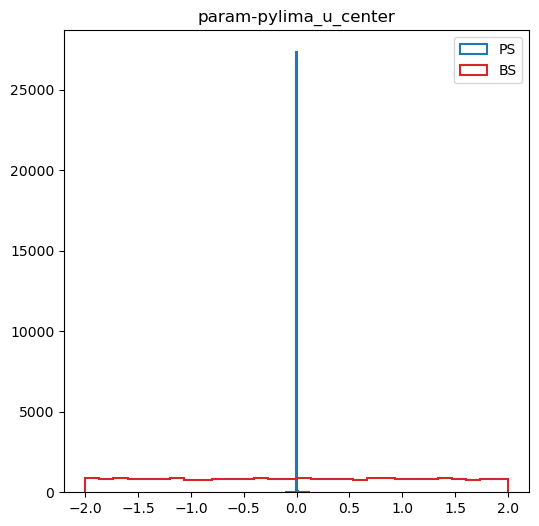

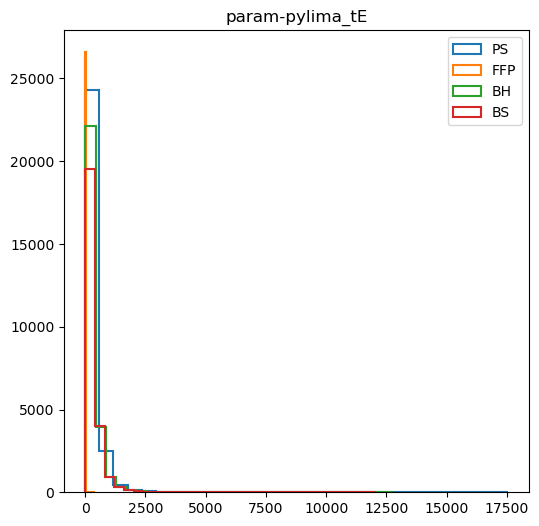

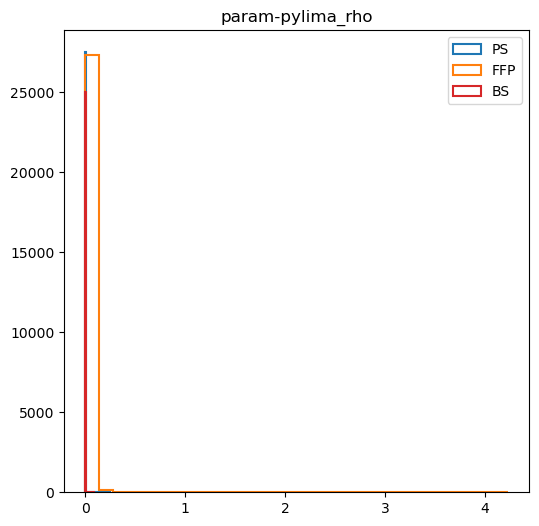

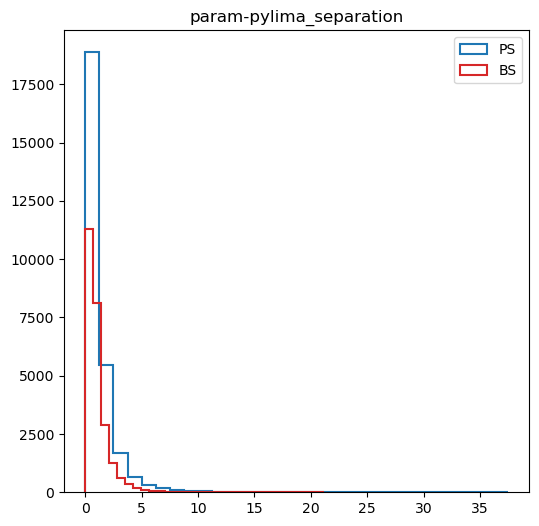

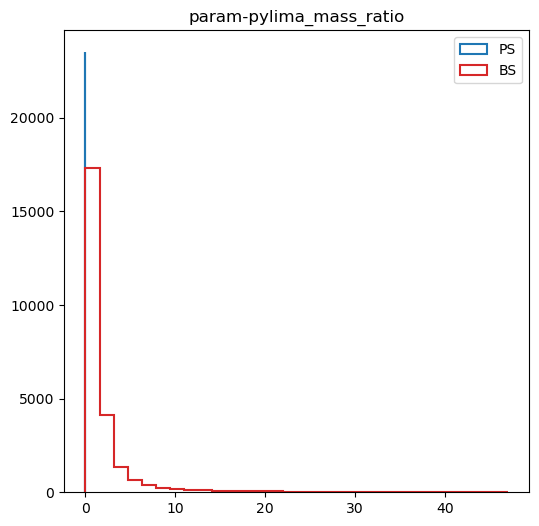

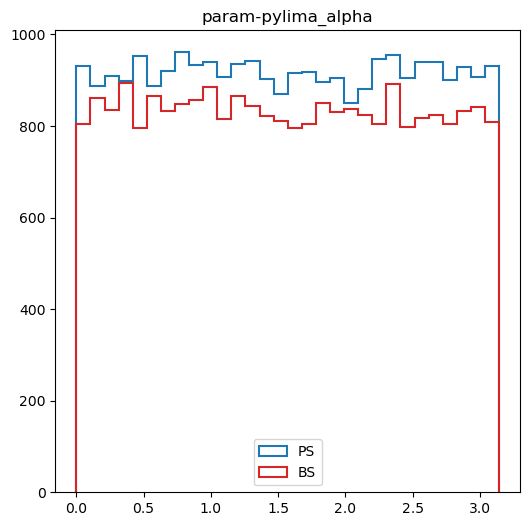

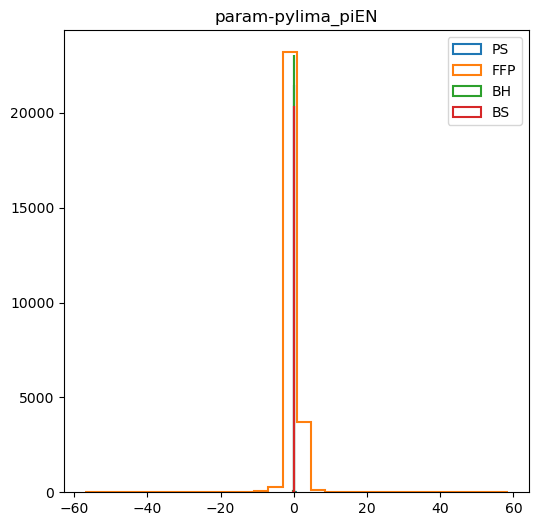

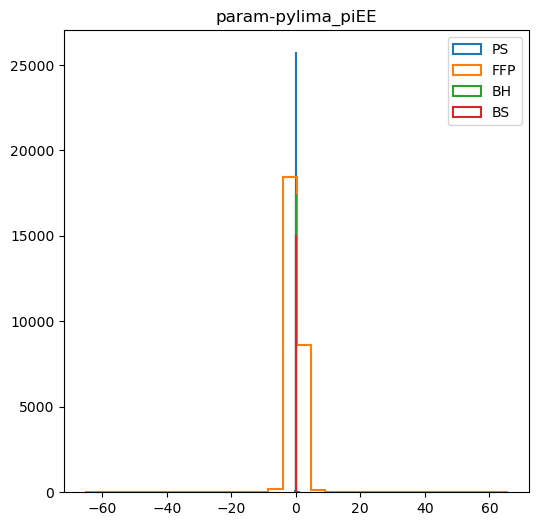

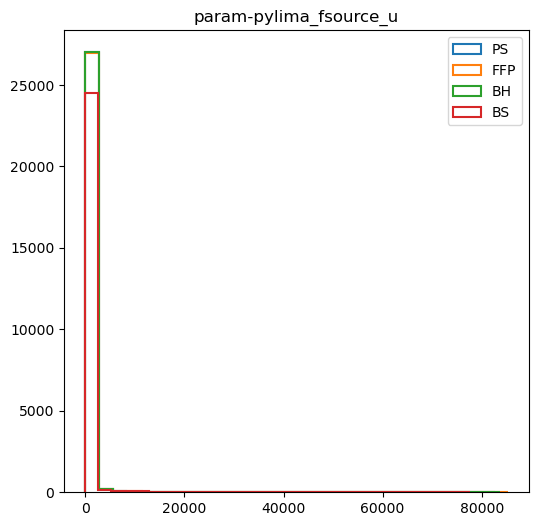

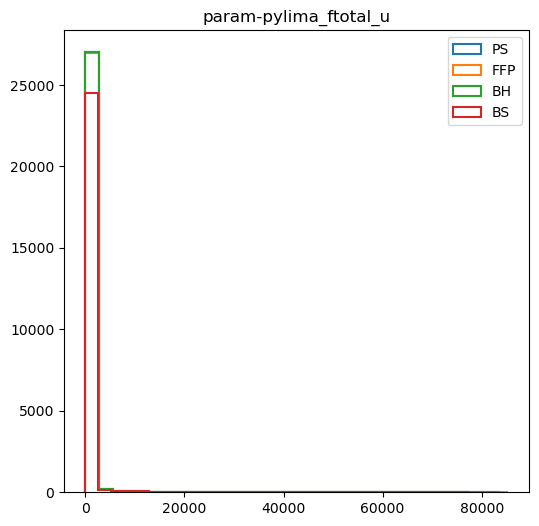

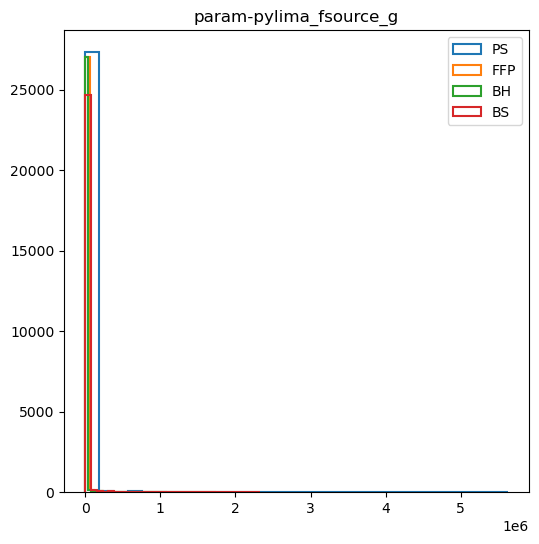

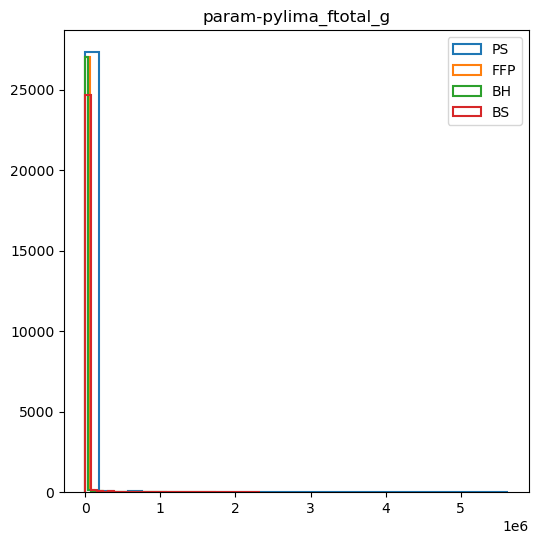

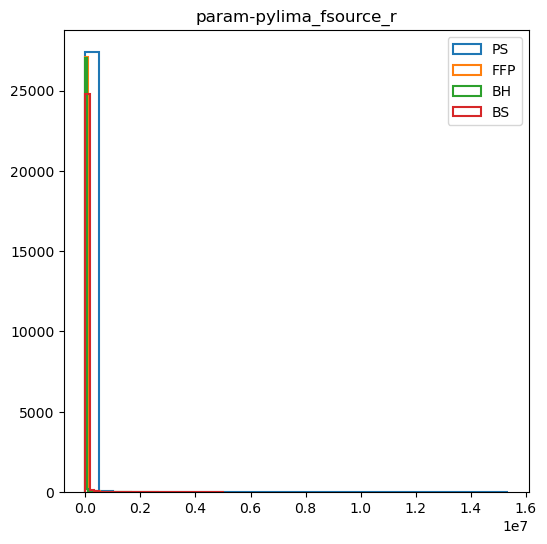

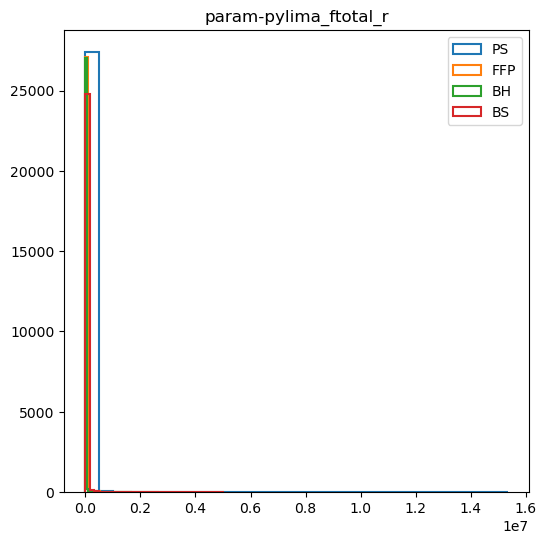

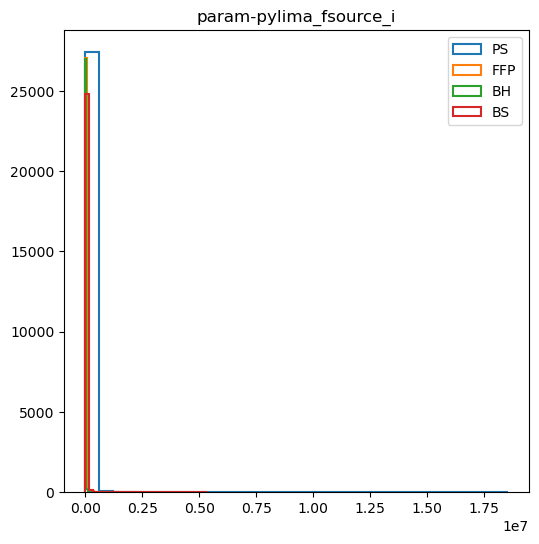

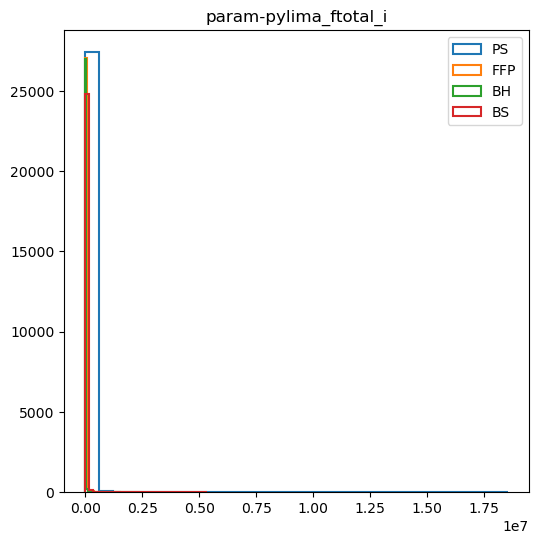

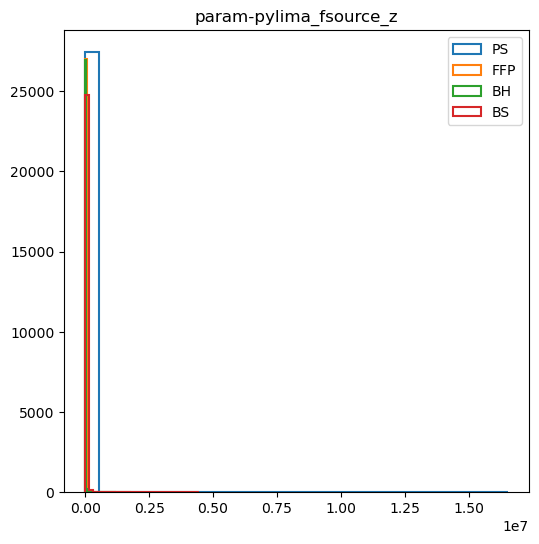

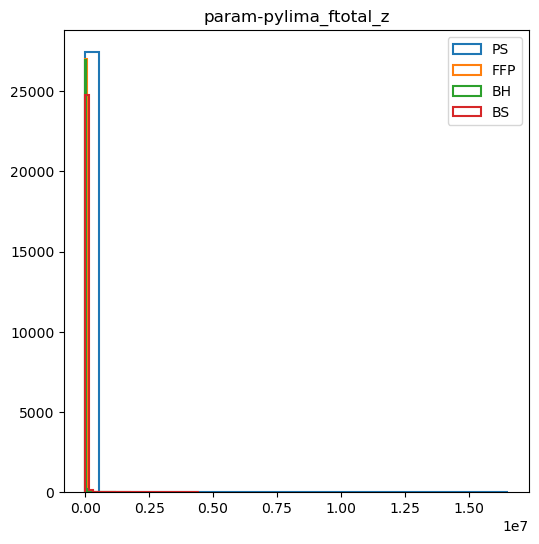

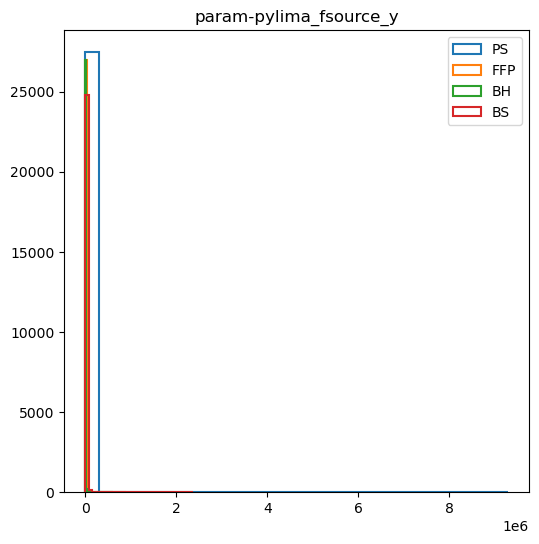

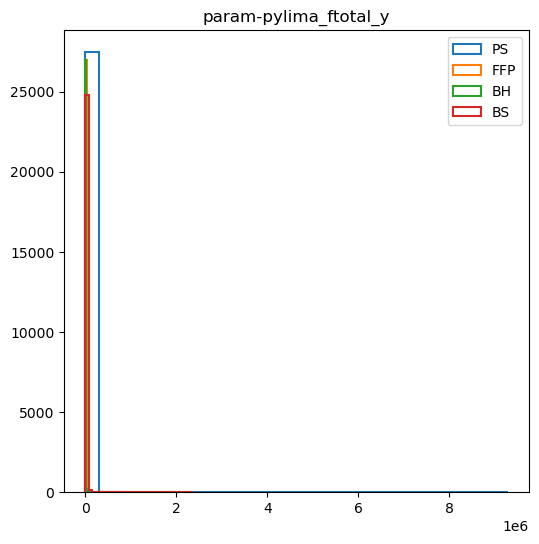

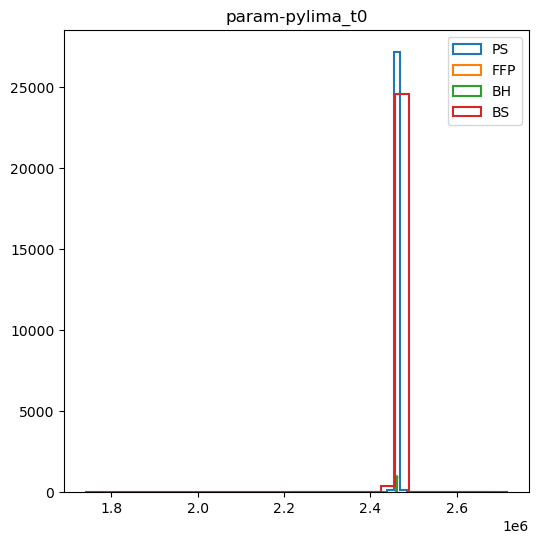

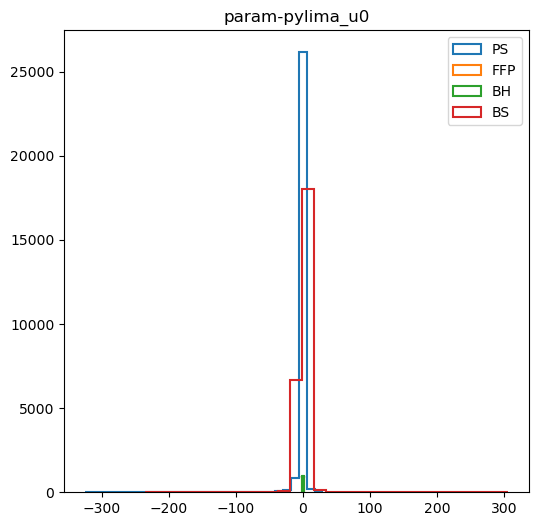

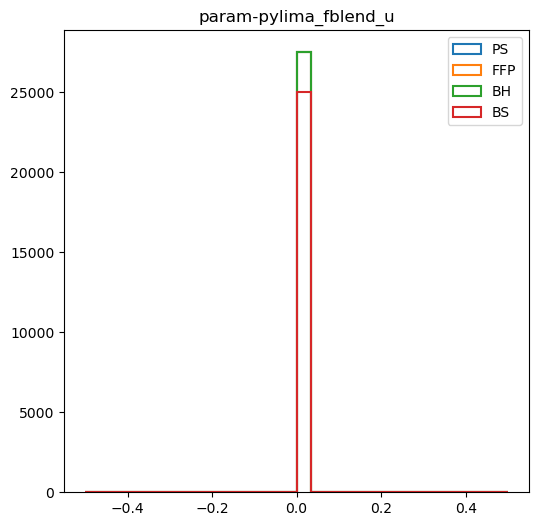

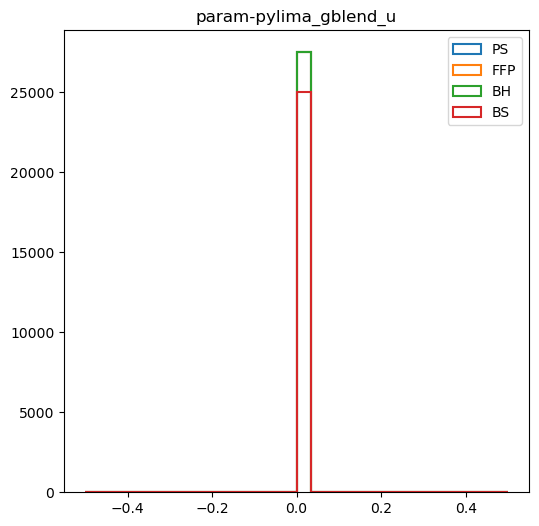

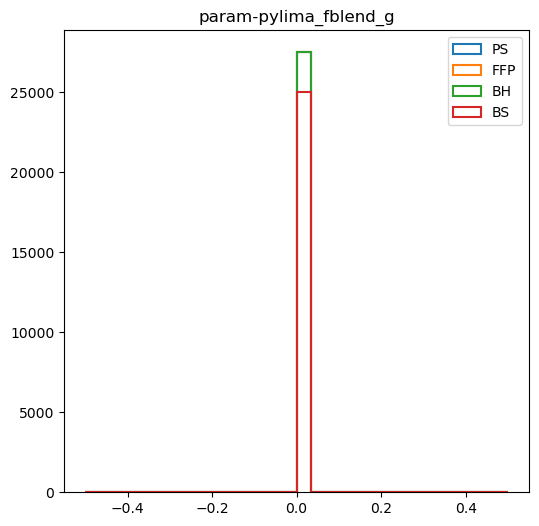

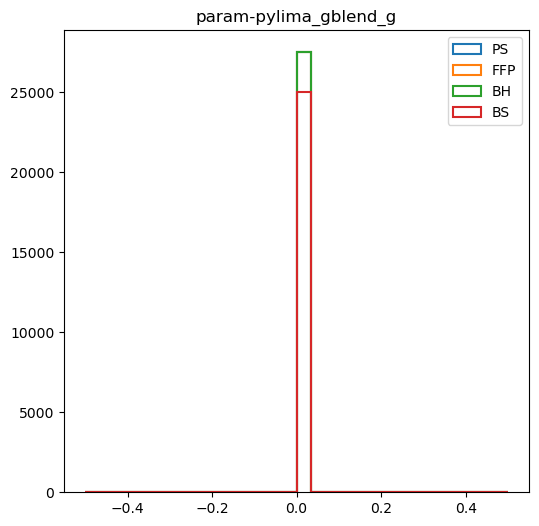

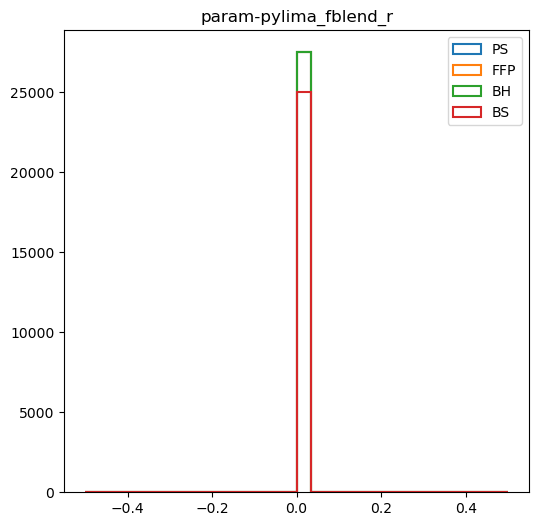

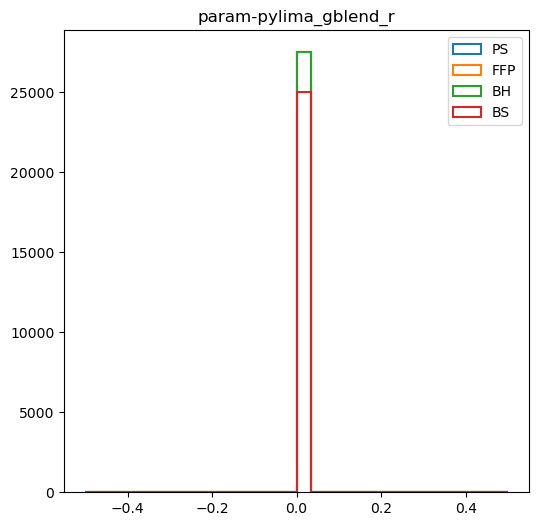

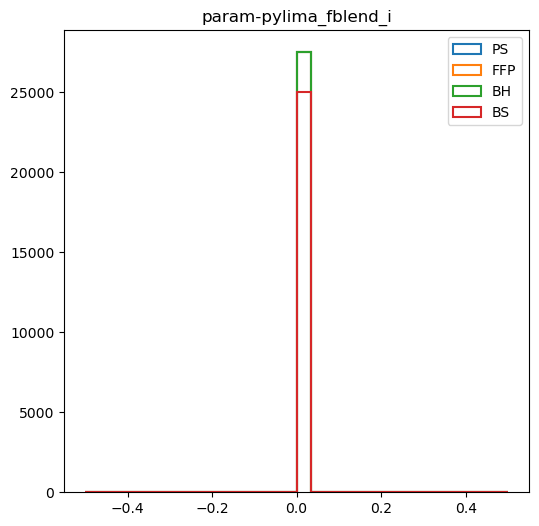

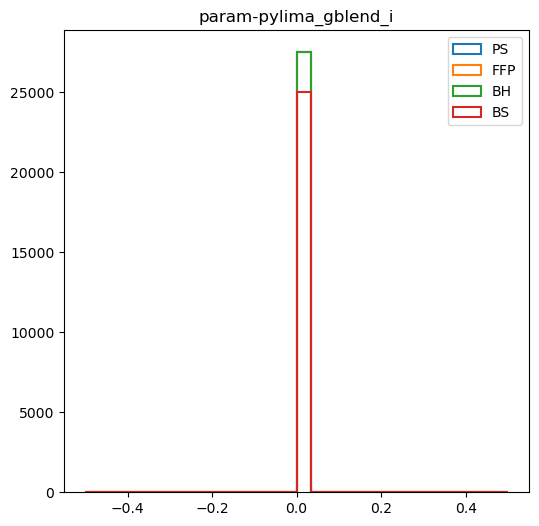

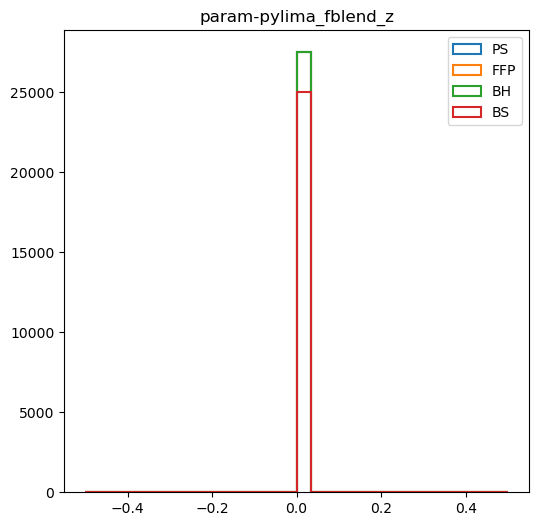

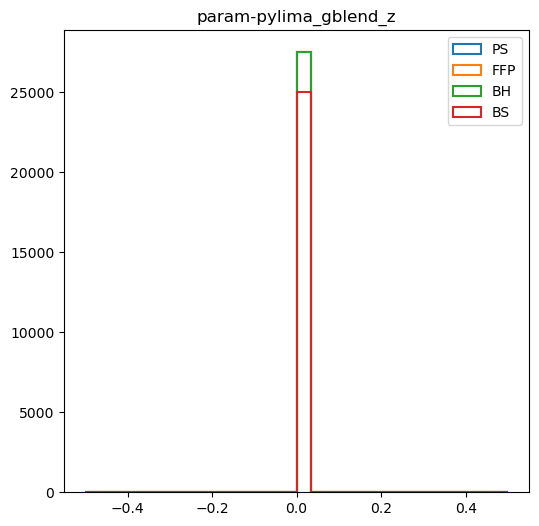

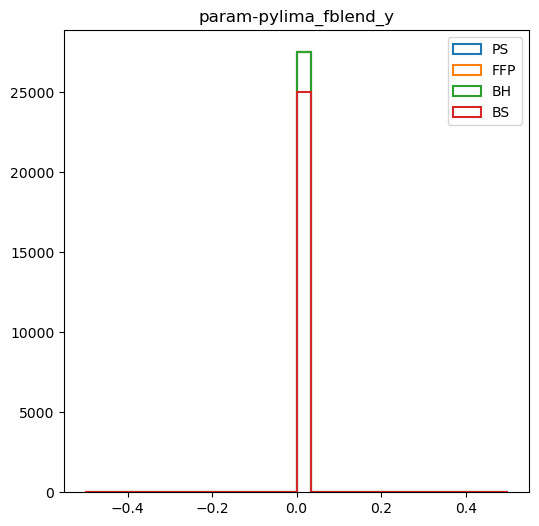

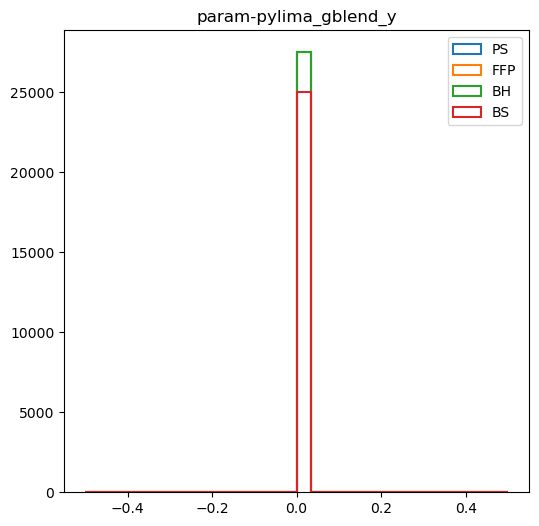

In [15]:
import pyarrow.parquet as pq
import matplotlib.pyplot as plt


de = pq.read_table(events_file).to_pandas()

param_cols = [col for col in de.columns if "param" in col]

system_types = de['system_type'].unique()
colors = plt.cm.tab10.colors

for col in param_cols:
    plt.figure(figsize=(6,6))
    plt.title(col)
    
    for i, stype in enumerate(system_types):
        subset = de[de['system_type'] == stype][col].dropna()  # <--- eliminar NaN
        if len(subset) == 0:
            continue  # saltear si no hay datos válidos
        plt.hist(subset, bins=30, histtype='step', 
                 color=colors[i % len(colors)], label=stype, linewidth=1.5)
    
    plt.legend()
    plt.show()
    
    